In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import glasbey
import seaborn as sns

import time
import pickle
import memory_profiler

%load_ext memory_profiler
from pathlib import Path

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from pubmed_retina.plotting import plot_tsne_colors
from pubmed_retina.exploration import *

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")

berenslab_data_path = Path("/gpfs01/berens/data/data/pubmed_processed")

In [ ]:
pwd

'/gpfs01/berens/user/rgonzalesmarquez/phd'

In [ ]:
# MANUAL FIX TO PATH ISSUE FROM VSCODE

nb_path = Path(
    "/gpfs01/berens/user/rgonzalesmarquez/phd/pubmed-retina/scripts"
)
assert nb_path.exists(), "The path does not exist"

variables_path = (nb_path / variables_path).resolve(strict=True)
figures_path = (nb_path / figures_path).resolve(strict=True)
data_path = (nb_path / data_path).resolve(strict=True)

In [ ]:
plt.style.use(nb_path / "matplotlib_style.txt")

# Import data

In [ ]:
%%time
%%memit

# df = pd.read_parquet(
#     berenslab_data_path / "pubmed_baseline_2025.parquet.gzip",
#     engine="pyarrow",
# )

# df = pd.read_csv(
#     berenslab_data_path / "pubmed_landscape_data_2024_v2.zip",
#     engine="pyarrow",
# )

df_abstracts_parquet = pd.read_parquet(
    berenslab_data_path / "pubmed_landscape_abstracts_2024.parquet.gzip",
    engine="pyarrow",
)

peak memory: 152850.07 MiB, increment: 62531.55 MiB
CPU times: user 2min 58s, sys: 1min 4s, total: 4min 2s
Wall time: 2min 41s


In [ ]:
print(df.PMID.iloc[0])
type(df.PMID.iloc[0])

24


numpy.int64

In [ ]:
df  # .head()

,Title,Journal,PMID,Year,x,y,Labels,Colors,Retractions,Countries,InferredGenderFirstAuthor,InferredGenderLastAuthor
0,Influence of a new virostatic compound on the ...,Arzneimittel-Forschung,24,1975,-37.297431,12.397200,unlabeled,#D3D3D3,False,unknown,unknown,unknown
1,Effect of etafenone on total and regional myoc...,Arzneimittel-Forschung,23,1975,8.703783,32.313807,unlabeled,#D3D3D3,False,unknown,unknown,unknown
2,Pharmacological properties of new neuroleptic ...,Arzneimittel-Forschung,25,1975,-139.371149,-18.888539,unlabeled,#D3D3D3,False,unknown,unknown,unknown
3,Lysosomal hydrolases of the epidermis. I. Glyc...,The British journal of dermatology,30,1975,-80.688904,2.023305,dermatology,#D790FF,False,unknown,unknown,unknown
4,A serum haemagglutinating property dependent u...,British journal of haematology,32,1975,-81.988885,-15.153657,unlabeled,#D3D3D3,False,unknown,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...
23389078,Does muscle-type myosin have ADPase activity?,Biochemical and biophysical research communica...,38096615,2023,-76.666872,15.689306,unlabeled,#D3D3D3,False,Russia,male,male
23389079,NDUFA8 is transcriptionally regulated by EP300...,Biochemical and biophysical research communica...,38096616,2023,-80.244742,162.294062,unlabeled,#D3D3D3,False,China,unknown,unknown
23389080,Nardilysin determines hematopoietic stem cell ...,Biochemical and biophysical research communica...,38096617,2023,-64.250156,98.992620,unlabeled,#D3D3D3,False,Japan,unknown,male
23389081,The role of integrin αvβ3 in biphasic calcium ...,Biomaterials,38096618,2023,-107.510047,93.890237,unlabeled,#D3D3D3,False,China,unknown,male


In [ ]:
abstracts = df_abstracts_parquet["AbstractText"]
labels = df.Labels
countries = df.Countries
years = df.Year

In [ ]:
print(abstracts.shape)  # = df_abstracts_parquet["AbstractText"]
print(labels.shape)  # = df.Labels
print(countries.shape)  # = df.Countries
print(years.shape)  # = df.Year

(23389083,)
(23389083,)
(23389083,)
(23389083,)


In [ ]:
tsne_sep = np.load(
    data_path / "tsne_bert_sep_2024.npy",
)

In [ ]:
tsne_sep.shape

(23389083, 2)

In [ ]:
tsne_rot = np.vstack((-tsne_sep[:, 1], -tsne_sep[:, 0])).T

# t-SNE

## Plots

(np.float64(-230.0), np.float64(230.0), np.float64(-230.0), np.float64(230.0))

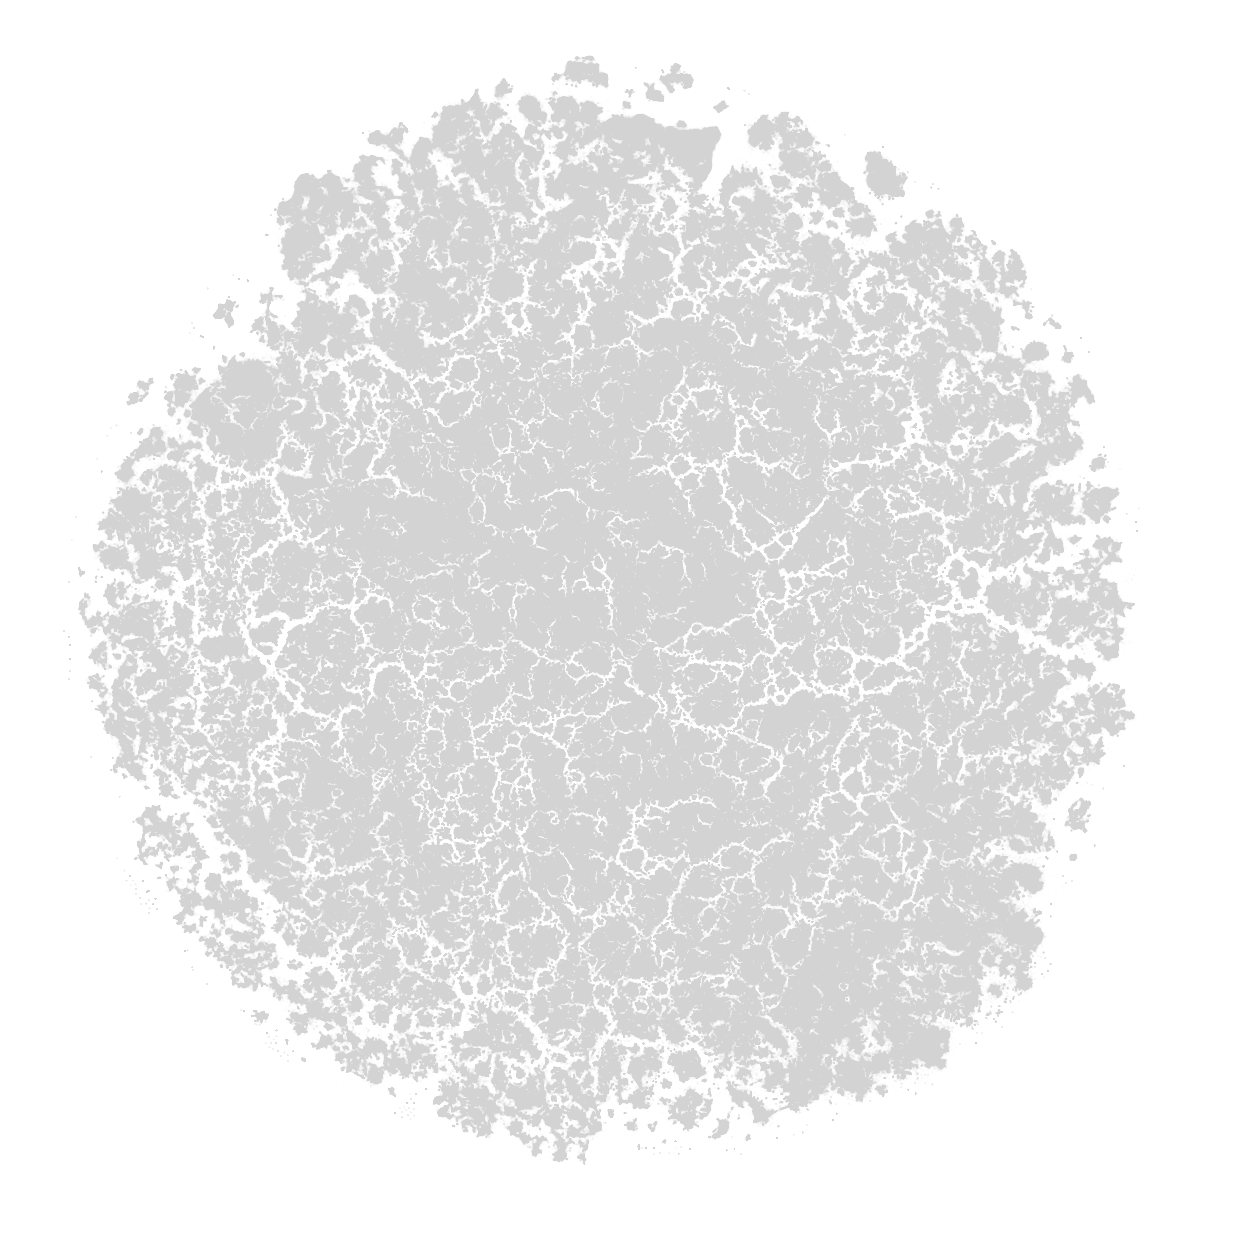

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(4, 4), dpi=300, layout="constrained")

txtkwargs = dict(size=8, weight="bold", va="top", ha="left")

# subplot b
x_lim = (-230, 230)
y_lim = (-230, 230)

s_grey = 0.5
alpha_grey = 0.02
s_color = 0.5
alpha_color = 0.1

tsne = tsne_sep
# all
ax.scatter(
    *tsne.T,
    c="lightgrey",
    s=s_grey,
    alpha=alpha_grey,
    marker=".",
    linewidths=0,
    rasterized=True,
    ec="None",
)

ax.axis("equal")
ax.set_xlim(x_lim[0], x_lim[1])
ax.set_ylim(y_lim[0], y_lim[1])
ax.axis("off")

### Colors based on class

In [ ]:
label_color_legend = {
    "cancer": "black",
    "neuroscience": "#aeaa00",
    "cardiology": "#1CE6FF",
    "ecology": "#FF34FF",
    "bioinformatics": "#FF4A46",
    "chemistry": "#008941",
    "surgery": "#006FA6",
    "environment": "#0089A3",
    "material": "#0000A6",
    "microbiology": "#B79762",
    "pediatric": "#004D43",
    "immunology": "#8FB0FF",
    "psychology": "#5A0007",
    "psychiatry": "#BA0900",
    "genetics": "#1B4400",
    "nutrition": "#4FC601",
    "veterinary": "#3B5DFF",
    "engineering": "#00C2A0",
    "education": "#549E79",
    "physics": "#BC23FF",
    "optics": "#C895C5",
    "nursing": "#FF2F80",
    "neurology": "#009271",
    "radiology": "#00FECF",
    "ophthalmology": "#A4E804",
    "gynecology": "#FFB500",
    "rehabilitation": "#6B002C",
    "pathology": "#FF9408",
    "anesthesiology": "#CC0744",
    "dermatology": "#D790FF",
    "pharmacology": "#5B4534",
    "physiology": "#E83000",
    "virology": "#6F0062",
    "biochemistry": "#b65141",
    "computation": "#C20078",
    "infectious": "#7A4900",
    "healthcare": "#FF90C9",
    "ethics": "#6508ba",
    "dentistry": "#8e4d8a",
}

In [ ]:
# mapping
# create colors
colors_class = np.vectorize(label_color_legend.get)(labels)

# add grey to the rest of papers
colors_class = np.where(colors_class == None, "lightgrey", colors_class)
colors_class = np.where(colors_class == "None", "lightgrey", colors_class)

# change 0 for 'unlabeled'
labels_with_unlabeled = np.where(
    colors_class == "lightgrey", "unlabeled", labels
)

In [ ]:
colors_class.shape

(23389083,)

In [ ]:
np.save(variables_path / "colors_class", colors_class)
f = open(variables_path / "label_color_legend.pkl", "wb")
pickle.dump(label_color_legend, f)
f.close()

AssertionError: Not valid `plot_type` value. Choose from [None, 'subplot_2'].

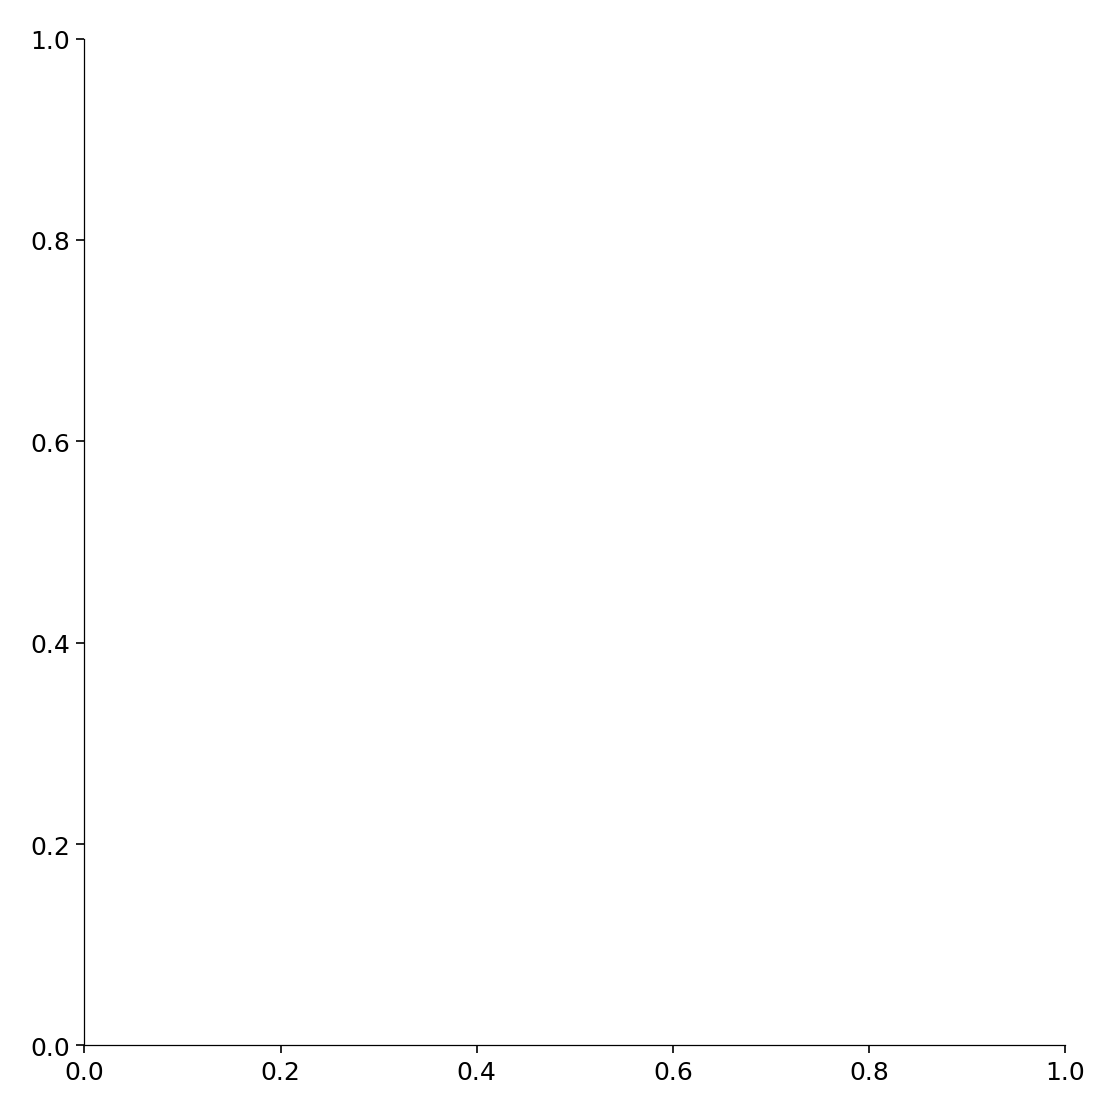

In [ ]:
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300, layout="constrained")

txtkwargs = dict(size=8, weight="bold", va="top", ha="left")

x_lim = (-230, 230)
y_lim = (-230, 230)
tsne = tsne_rot  # np.vstack((-tsne_sep[:, 0], -tsne_sep[:, 1])).T

# subplot a
plot_tsne_colors(
    tsne,
    colors_class,
    x_lim=x_lim,
    y_lim=y_lim,
    ax=ax,
    plot_type="subplot_3",
)

fig.savefig(figures_path / "tsne_2024_colored_by_class.png")

### Colors based on country

In [ ]:
country_color_legend = {
    "United States": "#1869ff",
    "China": "#d21820",
    "Japan": "#008a00",
    "United Kingdom": "#f36dff",
    "Germany": "#710079",
    "Italy": "#eba600",
    "Canada": "#00bec2",
    "France": "#45ef3d",
    "India": "#714900",
    "Australia": "#a2aeff",
}

In [ ]:
# mapping
# create colors
colors_country = np.vectorize(country_color_legend.get)(countries)

# add grey to the rest of papers
colors_country = np.where(colors_country == None, "lightgrey", colors_country)
colors_country = np.where(
    colors_country == "None", "lightgrey", colors_country
)

# change 0 for 'unlabeled'
labels_with_unlabeled = np.where(
    colors_country == "lightgrey", "unlabeled", countries
)

In [ ]:
%%time

# this makes all other countries in dark grey ("#474747") and the unknown ones in grey
colors_country_with_others = np.where(
    colors_country == "lightgrey",
    "#474747",
    colors_country,
)
colors_country_with_others = np.where(
    countries == "unknown",
    "lightgrey",
    colors_country_with_others,
)

CPU times: user 333 ms, sys: 72.9 ms, total: 406 ms
Wall time: 403 ms


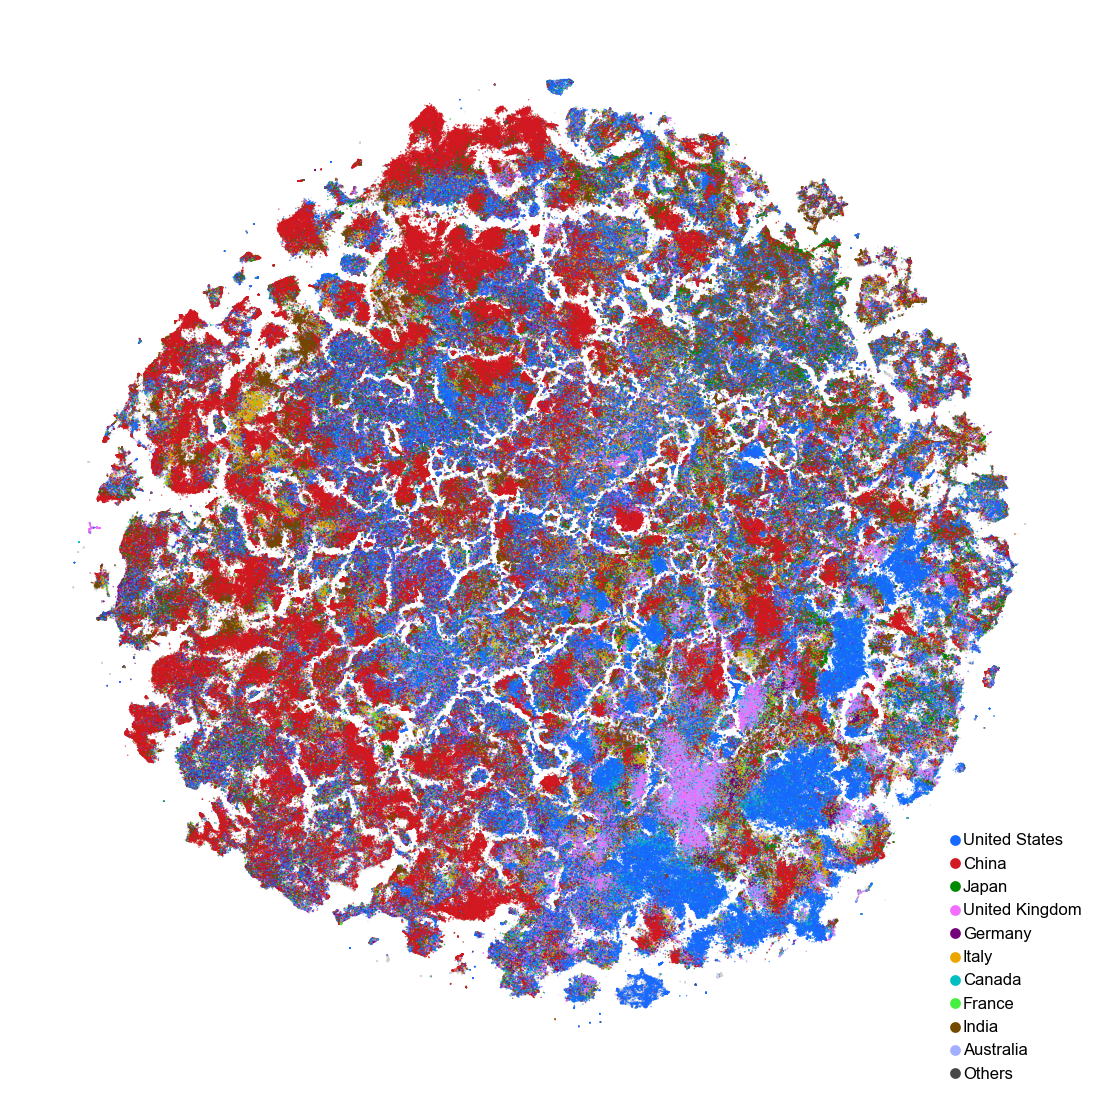

In [ ]:
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300, layout="constrained")

txtkwargs = dict(size=8, weight="bold", va="top", ha="left")

x_lim = (-230, 230)
y_lim = (-230, 230)

tsne = np.vstack((-tsne_sep[:, 0], -tsne_sep[:, 1])).T


# subplot a
plot_tsne_colors(
    tsne,
    colors_country,
    x_lim=x_lim,
    y_lim=y_lim,
    ax=ax,
    plot_type="subplot_3",
)

all_keys = []
for key, value in country_color_legend.items():
    key = ax.scatter([], [], c=value, s=10, alpha=1, label=key)
    all_keys.append(key)

key = ax.scatter([], [], c="#474747", s=10, alpha=1, label="Others")
all_keys.append(key)
ax.legend(
    handles=all_keys,
    loc="lower right",
    fontsize=4,
    frameon=False,
    borderpad=0.2,
    handletextpad=0,
    handlelength=1,
    borderaxespad=-0.2,
)

fig.savefig(figures_path / "tsne_2024_colored_by_country.png")

# Exploration
word: retina

In [ ]:
mask_retina = find_mask_words(abstracts_year, 'retina', verbose=True)

In [ ]:
np.save(variables_path / "mask_retina" , mask_retina) 

## Animals

In [ ]:
# Dictionary of animals used in retinal research organized by family
retinal_research_animals = {
    "Mammals": [
        "mouse",
        "rat",
        "rabbit",
        "cat",
        "dog",
        "ferret",
        "ground squirrel",
        "tree shrew",
        "guinea pig",
        "monkey",
        "macaque",
        "marmoset",
        "baboon",
        "pig",
        "cow",
    ],
    "Birds": ["chicken", "pigeon", "zebra finch", "owl"],
    "Fish": [
        "zebrafish",
        "goldfish",
        "cichlid",
        "rainbow trout",
        "killifish",
        "medaka",
    ],
    "Amphibians": ["frog", "xenopus", "salamander"],
    "Reptiles": ["gecko", "chameleon", "turtle"],
    "Insects": [
        "fruit fly",
        "honeybee",
        "dragonfly",
        "horseshoe crab",
        "locust",
        "butterfly",
        "moth",
        "praying mantis",
    ],
    "Cephalopods": ["octopus", "squid", "cuttlefish"],
    "Crustaceans": ["crayfish", "crab", "lobster"],
}

# Dictionary mapping species names to alternative forms (singular, plural, scientific names)
species_forms = {
    "mouse": ["mouse", "mice", "Mus musculus"],
    "rat": ["rat", "rats", "Rattus norvegicus"],
    "rabbit": ["rabbit", "rabbits", "Oryctolagus cuniculus"],
    "cat": ["cat", "cats", "Felis catus"],
    "dog": ["dog", "dogs", "Canis lupus familiaris"],
    "ferret": ["ferret", "ferrets", "Mustela putorius furo"],
    "ground squirrel": [
        "ground squirrel",
        "ground squirrels",
        "Ictidomys tridecemlineatus",
    ],
    "tree shrew": ["tree shrew", "tree shrews", "Tupaia belangeri"],
    "guinea pig": ["guinea pig", "guinea pigs", "Cavia porcellus"],
    "monkey": ["monkey", "monkeys", "Primates"],
    "macaque": [
        "macaque",
        "macaques",
        "Macaca mulatta",
        "Macaca fascicularis",
    ],
    "marmoset": ["marmoset", "marmosets", "Callithrix jacchus"],
    "baboon": ["baboon", "baboons", "Papio"],
    "pig": ["pig", "pigs", "Sus scrofa domesticus"],
    "cow": ["cow", "cows", "Bos taurus"],
    "chicken": ["chicken", "chickens", "Gallus gallus domesticus"],
    "pigeon": ["pigeon", "pigeons", "Columba livia"],
    "zebra finch": ["zebra finch", "zebra finches", "Taeniopygia guttata"],
    "owl": ["owl", "owls", "Strigiformes"],
    "zebrafish": ["zebrafish", "zebrafish", "Danio rerio"],
    "goldfish": ["goldfish", "goldfish", "Carassius auratus"],
    "cichlid": ["cichlid", "cichlids", "Cichlidae"],
    "rainbow trout": ["rainbow trout", "rainbow trout", "Oncorhynchus mykiss"],
    "killifish": ["killifish", "killifish", "Fundulus heteroclitus"],
    "medaka": ["medaka", "medaka", "Oryzias latipes"],
    "frog": ["frog", "frogs", "Anura"],
    "xenopus": ["xenopus", "xenopus", "Xenopus laevis"],
    "salamander": ["salamander", "salamanders", "Ambystoma tigrinum"],
    "gecko": ["gecko", "geckos", "Gekkonidae"],
    "chameleon": ["chameleon", "chameleons", "Chamaeleonidae"],
    "turtle": ["turtle", "turtles", "Testudines"],
    "fruit fly": ["fruit fly", "fruit flies", "Drosophila melanogaster"],
    "honeybee": ["honeybee", "honeybees", "Apis mellifera"],
    "dragonfly": ["dragonfly", "dragonflies", "Anisoptera"],
    "horseshoe crab": [
        "horseshoe crab",
        "horseshoe crabs",
        "Limulus polyphemus",
    ],
    "locust": ["locust", "locusts", "Schistocerca gregaria"],
    "butterfly": ["butterfly", "butterflies", "Lepidoptera"],
    "moth": ["moth", "moths", "Lepidoptera"],
    "praying mantis": [
        "praying mantis",
        "praying mantises",
        "Mantis religiosa",
    ],
    "octopus": ["octopus", "octopuses", "octopi", "Octopoda"],
    "squid": ["squid", "squids", "squid", "Teuthida"],
    "cuttlefish": ["cuttlefish", "cuttlefish", "Sepiida"],
    "crayfish": ["crayfish", "crayfish", "Astacoidea"],
    "crab": ["crab", "crabs", "Brachyura"],
    "lobster": ["lobster", "lobsters", "Nephropidae"],
}

In [ ]:
import re
import pandas as pd
from typing import List, Dict, Union
import time


def label_texts_with_animals(
    texts: pd.Series,
    animals_to_check: List[str],
    species_forms: Dict[str, List[str]],
) -> pd.Series:
    """
    Label texts based on animal mentions using regex pattern matching.

    Args:
        texts: Pandas Series containing the texts to analyze
        animals_to_check: List of animal keys to search for
        species_forms: Dictionary mapping each animal key to its various forms

    Returns:
        Pandas Series with labels for each text
    """
    # # Start timing for performance measurement
    # start_time = time.time()

    # # Filter the species_forms dictionary to only include the animals we're checking
    filtered_species_forms = {
        k: v for k, v in species_forms.items() if k in animals_to_check
    }

    # Pre-compile all regex patterns for efficiency
    # Build a dictionary mapping animal keys to their compiled regex patterns
    pattern_dict = {}
    for animal, forms in filtered_species_forms.items():
        # Create a pattern that matches word boundaries around each form
        # Using word boundaries to avoid matching substrings
        patterns = [r"\b" + re.escape(form) + r"\b" for form in forms]
        combined_pattern = "|".join(patterns)
        pattern_dict[animal] = re.compile(combined_pattern, re.IGNORECASE)

    # Initialize labels array
    labels = ["unlabeled"] * len(texts)

    # Process each text
    for i, text in enumerate(texts):
        # Skip if text is not a string
        if not isinstance(text, str):
            continue

        # Check for each animal pattern
        for animal, pattern in pattern_dict.items():
            # If pattern found, assign label and break the inner loop
            if pattern.search(text):
                labels[i] = animal
                break

    # Convert labels to pandas Series
    # result = pd.Series(labels, index=texts.index)

    # # Print execution time for performance monitoring
    # execution_time = time.time() - start_time
    # print(f"Labeling completed in {execution_time:.2f} seconds")

    return labels

In [ ]:
%%time
# Example usage:
# Extract all animal names to check from all categories
all_animals = []
for category in retinal_research_animals.values():
    all_animals.extend(category)

print(all_animals)

# Example texts (in real use case this would be your pandas Series)
example_texts = pd.Series(
    [
        "The experiment was conducted using mice (Mus musculus) as the primary model.",
        "We analyzed the retinal response in zebrafish embryos.",
        "The salamander visual system provides excellent insights into rod function.",
        "This paper does not involve any animal models.",
        "Macaques were used for the comparative study.",
    ]
)

# Apply the labeling function
labels = label_texts_with_animals(example_texts, all_animals, species_forms)
print(labels)

# """
# # Result:
# # 0      mouse
# # 1    zebrafish
# # 2    salamander
# # 3    unlabeled
# # 4      macaque
# # dtype: object
# """

['mouse', 'rat', 'rabbit', 'cat', 'dog', 'ferret', 'ground squirrel', 'tree shrew', 'guinea pig', 'monkey', 'macaque', 'marmoset', 'baboon', 'pig', 'cow', 'chicken', 'pigeon', 'zebra finch', 'owl', 'zebrafish', 'goldfish', 'cichlid', 'rainbow trout', 'killifish', 'medaka', 'frog', 'xenopus', 'salamander', 'gecko', 'chameleon', 'turtle', 'fruit fly', 'honeybee', 'dragonfly', 'horseshoe crab', 'locust', 'butterfly', 'moth', 'praying mantis', 'octopus', 'squid', 'cuttlefish', 'crayfish', 'crab', 'lobster']
['mouse', 'zebrafish', 'salamander', 'unlabeled', 'macaque']
CPU times: user 1.76 ms, sys: 0 ns, total: 1.76 ms
Wall time: 1.65 ms


In [ ]:
type(labels)

list

In [ ]:
# More efficient version for very large datasets using vectorized operations
def label_texts_with_animals_vectorized(
    texts: pd.Series,
    animals_to_check: List[str],
    species_forms: Dict[str, List[str]],
) -> pd.Series:
    """
    Vectorized version for labeling texts based on animal mentions.
    This version is more efficient for very large datasets.

    Args:
        texts: Pandas Series containing the texts to analyze
        animals_to_check: List of animal keys to search for
        species_forms: Dictionary mapping each animal key to its various forms

    Returns:
        Pandas Series with labels for each text
    """
    # start_time = time.time()

    # Initialize results with "unlabeled"
    results = np.array(["unlabeled"] * len(texts))

    # Filter to only relevant animals
    filtered_species_forms = {
        k: v for k, v in species_forms.items() if k in animals_to_check
    }

    # Ensure texts are strings
    texts = texts.fillna("").astype(str)

    # Process each animal in priority order
    for animal, forms in filtered_species_forms.items():
        # Create regex patterns for each form
        patterns = [r"\b" + re.escape(form) + r"\b" for form in forms]
        combined_pattern = "|".join(patterns)

        # Create a mask for texts that have this animal and haven't been labeled yet
        mask = (
            texts.str.contains(combined_pattern, case=False, regex=True)
        ) & (results == "unlabeled")

        # Apply the animal label where the mask is True
        results[mask] = animal

    # execution_time = time.time() - start_time
    # print(f"Vectorized labeling completed in {execution_time:.2f} seconds")

    return results

In [ ]:
%%time
# Example usage:
# Extract all animal names to check from all categories
all_animals = []
for category in retinal_research_animals.values():
    all_animals.extend(category)

print(all_animals)

# Example texts (in real use case this would be your pandas Series)
example_texts = pd.Series(
    [
        "The experiment was conducted using mice (Mus musculus) as the primary model.",
        "We analyzed the retinal response in zebrafish embryos.",
        "The salamander visual system provides excellent insights into rod function.",
        "This paper does not involve any animal models.",
        "Macaques were used for the comparative study.",
    ]
)

# Apply the labeling function
labels = label_texts_with_animals_vectorized(
    example_texts, all_animals, species_forms
)
print(labels)

# """
# # Result:
# # 0      mouse
# # 1    zebrafish
# # 2    salamander
# # 3    unlabeled
# # 4      macaque
# # dtype: object
# """

['mouse', 'rat', 'rabbit', 'cat', 'dog', 'ferret', 'ground squirrel', 'tree shrew', 'guinea pig', 'monkey', 'macaque', 'marmoset', 'baboon', 'pig', 'cow', 'chicken', 'pigeon', 'zebra finch', 'owl', 'zebrafish', 'goldfish', 'cichlid', 'rainbow trout', 'killifish', 'medaka', 'frog', 'xenopus', 'salamander', 'gecko', 'chameleon', 'turtle', 'fruit fly', 'honeybee', 'dragonfly', 'horseshoe crab', 'locust', 'butterfly', 'moth', 'praying mantis', 'octopus', 'squid', 'cuttlefish', 'crayfish', 'crab', 'lobster']
['mouse' 'zebrafish' 'salamande' 'unlabeled' 'macaque']
CPU times: user 29.1 ms, sys: 1.01 ms, total: 30.1 ms
Wall time: 28.8 ms


In [ ]:
import re
import pandas as pd
from typing import List, Dict, Union
import time


# More efficient version for very large datasets using vectorized operations
def label_texts_with_animals_vectorized(
    texts: pd.Series,
    animals_to_check: List[str],
    species_forms: Dict[str, List[str]],
    multilabel: bool = False,
) -> Union[pd.Series, pd.DataFrame]:
    """
    Vectorized version for labeling texts based on animal mentions.
    This version is more efficient for very large datasets.

    Args:
        texts: Pandas Series containing the texts to analyze
        animals_to_check: List of animal keys to search for
        species_forms: Dictionary mapping each animal key to its various forms
        multilabel: If True, returns a DataFrame with animal presence indicated by True/False
                   If False, returns a Series with the first animal found for each text

    Returns:
        If multilabel=False: Pandas Series with single label for each text
        If multilabel=True: Pandas DataFrame with boolean columns for each animal
    """
    # start_time = time.time()

    # Filter to only relevant animals
    filtered_species_forms = {
        k: v for k, v in species_forms.items() if k in animals_to_check
    }

    # Ensure texts are strings
    texts = texts.fillna("").astype(str)

    if multilabel:
        # Create a DataFrame to store results, initialized with all False
        results = pd.DataFrame(
            False, index=texts.index, columns=animals_to_check
        )

        # Process each animal
        for animal, forms in filtered_species_forms.items():
            # Create regex patterns for each form
            patterns = [r"\b" + re.escape(form) + r"\b" for form in forms]
            combined_pattern = "|".join(patterns)

            # Set True for texts that contain this animal
            results[animal] = texts.str.contains(
                combined_pattern, case=False, regex=True
            )

    else:
        # Initialize results with "unlabeled"
        results = pd.Series(["unlabeled"] * len(texts), index=texts.index)

        # Process each animal in priority order
        for animal, forms in filtered_species_forms.items():
            # Create regex patterns for each form
            patterns = [r"\b" + re.escape(form) + r"\b" for form in forms]
            combined_pattern = "|".join(patterns)

            # Create a mask for texts that have this animal and haven't been labeled yet
            mask = (
                texts.str.contains(combined_pattern, case=False, regex=True)
            ) & (results == "unlabeled")

            # Apply the animal label where the mask is True
            results[mask] = animal

    # execution_time = time.time() - start_time
    # print(f"Vectorized labeling completed in {execution_time:.2f} seconds")

    return results

In [ ]:
# Example usage:

# Extract all animal names to check from all categories
all_animals = []
for category in retinal_research_animals.values():
    all_animals.extend(category)

# Example texts (in real use case this would be your pandas Series)
example_texts = pd.Series(
    [
        "The experiment was conducted using mice (Mus musculus) as the primary model.",
        "We analyzed the retinal response in zebrafish embryos.",
        "The salamander visual system provides excellent insights into rod function.",
        "This paper does not involve any animal models.",
        "Macaques were used for the comparative study with mice.",
    ]
)

# Single label example (default behavior)
labels = label_texts_with_animals_vectorized(
    example_texts, all_animals, species_forms
)
print("Single label results:")
print(labels)

# Multi-label example
multilabel_results = label_texts_with_animals_vectorized(
    example_texts, all_animals, species_forms, multilabel=True
)
print("\nMulti-label results:")
print(multilabel_results)

# Results will show:
# - In single label mode: First animal found in each text
# - In multi-label mode: All animals found in each text (True/False for each animal)

Vectorized labeling completed in 0.04 seconds
Single label results:
0         mouse
1     zebrafish
2    salamander
3     unlabeled
4         mouse
dtype: object
Vectorized labeling completed in 0.02 seconds

Multi-label results:
   mouse    rat  rabbit    cat    dog  ferret  ground squirrel  tree shrew  \
0   True  False   False  False  False   False            False       False   
1  False  False   False  False  False   False            False       False   
2  False  False   False  False  False   False            False       False   
3  False  False   False  False  False   False            False       False   
4   True  False   False  False  False   False            False       False   

   guinea pig  monkey  ...  locust  butterfly   moth  praying mantis  octopus  \
0       False   False  ...   False      False  False           False    False   
1       False   False  ...   False      False  False           False    False   
2       False   False  ...   False      False  False      